## Leave-one-out error for PCA and Factor Analysis for reconstructing neuron fluorescence trace

Dataset provided is calcium imaging traces of 332 neurons over 30 mins of mouse V1/somatosensory cortex recording without stimulation.

We compare methods using the goodness-of-fit metric following [Yu et al. (2009) ](https://pmc.ncbi.nlm.nih.gov/articles/PMC2712272/#f4). Figure 5 in that paper is an example of the type of comparison we aim to make here.



In [24]:
# Load dat
import numpy as np
import scipy
from scipy.io import loadmat
import matplotlib.pyplot as plt


dataset = "Neuron_Act_Info.mat" # replace with your filepath
data = loadmat(dataset)["Neuron_Act_Info"][0][0]
roi_mask, neuron_activity, max_value = data

print ("ROI Mask shape: ", roi_mask.shape) # neuron number # is annotated in roi_mask
print ("Neuron activity shape: ", neuron_activity.shape) # data is ~30 Hz reading
print ("Max value.shape: ", max_value.shape)
neuron_range = int(np.amin(roi_mask)), int(np.amax(roi_mask))
print ("Neuron ID # range: ", neuron_range)


ROI Mask shape:  (512, 512)
Neuron activity shape:  (332, 53400)
Max value.shape:  (332, 1)
Neuron ID # range:  (0, 332)


## Decide common data splits, features and neurons to analyze

Recent approach is to randomly sample 80% of the data and leave out 20%. Then, randomly select n_subsets groups of n_neurons_per_group neurons. This allows us to determine the variance of the error metric based upon the number of holdout neurons.


In [25]:
np.random.seed(42)
test_n_pcs = [1, 3, 5, 10, 30, 50, 60, 80, 100, 200]
# test_n_pcs = [1, 50]
train_times = [0.8]
n_subsets = 10
n_neurons_per_group = 30

selected_neurons = [] # len should be n_subsets, where each component list has len n_neurons_per_group
# if n_subsets * n_neurons_per_group > neuron_range[1]:
#   raise ValueError("Not enough neurons to sample")

for i in range(n_subsets): # could be overlapping, for now?
  np.random.seed(i)
  selected_neurons.append(np.random.choice(np.arange(neuron_range[1]), size=n_neurons_per_group, replace=False))
  print (selected_neurons[-1])

np.random.seed(42)
decomposition_dataset = neuron_activity.T
k = 1 # subsampling, not used so far in analysis
train_datatimes = np.random.choice(np.arange(decomposition_dataset.shape[0]), size=int(0.8 * decomposition_dataset.shape[0]) , replace=False)
test_datatimes = np.setdiff1d(np.arange(decomposition_dataset.shape[0]), train_datatimes) # choose times not selected for training as test (remaining 20%)
decomposition_dataset = decomposition_dataset[::k, :] # subsample to 30/k Hz
decomposition_train = decomposition_dataset[train_datatimes, :]
decomposition_test = decomposition_dataset[test_datatimes, :]
print ("Train Dataset shape: ", decomposition_train.shape)
print ("Test Dataset shape: ", decomposition_test.shape)
print ("Selected neurons: ", selected_neurons)
assert len(selected_neurons) == n_subsets
assert len(selected_neurons[0]) == n_neurons_per_group


[ 52  56  55 191 145  15 101 124 224  76 173 134 298 102 158 194  78 253
  74 168 208 167 166 161 271 198  26 326 223 270]
[ 59 268 180 192 284 177  92 187  89 189 213   4  58 167 206 158 186 174
   6 120 260 119 107 102 111  18 307  11 298 244]
[276 217   7 181  65 142 153  66 144  89  91  94 179 141  30 283  69 284
 118 242 230 215 315 157 146   3 303 301  84 312]
[118 198 300  15  84  31 201  56 270 286  24 134  55 210 324 264 295 268
 320 194 301 114 329 246 237  16 102 325 195 279]
[195 123  64  47 290  61 302 129   6  13  68  14 270  93 162 188 226 101
  72  70 112  63  18  84 318 238  11  66 245 221]
[ 53  99 296 226  21  60 240 331 132  56 174 269 162 313  71 259  50 297
 115 306  42 285 127 154 138 107 237 193 222 301]
[ 90 270 283 255 163  74 166 134 146 286 154   4 139 248 268 116 244 152
  93 305  56 249 188  30 200 302 314 247 243  83]
[303 243  65  73 326 170 138  30 236  60 273 329 188 305  28 114 159   3
 276  57 283 324 330  86 256 155 327 300  84 200]
[  0  25 330 165

The cells should be  [ 25, 317,  73, 193,  57, 165, 280, 179, 209, 195] if you use seed 42 and should add to those cells if you use a larger set. Feel free to change the seed or try larger sets.

In [26]:
### CURRENT VERSION
from sklearn.decomposition import FactorAnalysis, PCA, NMF
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def test_method(method, n_components, verbose=False):
  '''
  Evaluates the performance of a dimensionality reduction method (PCA or FactorAnalysis)
  on predicting held-out neuron activity using linear regression.

  Args:
    method: The dimensionality reduction method class (PCA or FactorAnalysis).
    n_components: The number of components to use for dimensionality reduction (unused in the current implementation).
    verbose: If True, prints progress during execution.

  Returns:
    A list of lists containing the average mean squared error for each combination
    of training time ratio and number of components.
  '''
  plot_errors = []
  plot_error_std = []
  for n_components in test_n_pcs:
    if method == PCA:
        decomposition_method = method(n_components=n_components, svd_solver='randomized')
    elif method == FactorAnalysis:
        decomposition_method = method(n_components=n_components, svd_method="randomized", max_iter=1000, tol=1e-2) # default params except solver but changeable for speed
    else:
        raise ValueError("Unsupported method")

    line = LinearRegression()
    errors = []
    for sample_neuron_set in selected_neurons: # holding out groups of sampled neurons for quicker evaluation
      training_neurons = np.setdiff1d(np.arange(neuron_range[1]), sample_neuron_set)
      assert len(training_neurons) == neuron_range[1] - n_neurons_per_group
      # form training set of data until train_time (actually a number of frames), using all neurons except sample_neuron
      train_transformed = decomposition_method.fit_transform(decomposition_train[:, training_neurons])
      # Fit a line from the n_components at each timepoint to the sample_neuron's calcium activity at each timepoint.
      # the weight has dims (n_components, n_neurons) which yields vector of (n_timepoints, n_sample_neurons), i.e. sample_neurons' activity in each timepoint.
      line.fit(train_transformed, decomposition_train[:, sample_neuron_set])

      # now that we have fitted parameters, test the method in the heldout data with the same process
      z = decomposition_method.transform(decomposition_test[:, training_neurons])
      prediction_ = line.predict(z)
      error = np.sum(np.square(prediction_ - decomposition_test[:, sample_neuron_set]), axis=0) # unnormalized per neuron error, shape is same size as (sample_neuron_set)
      assert error.shape[0] == n_neurons_per_group
      errors.append(np.mean(error)) # average error over all neurons in the group

    # Compute cumulative variance explained from the last fitted model (representative subset)
    if method == PCA:
      cumvar = np.sum(decomposition_method.explained_variance_ratio_)
    elif method == FactorAnalysis:
      loadings = decomposition_method.components_
      component_var = np.sum(loadings ** 2, axis=1)
      cumvar = component_var.sum() / (component_var.sum() + np.sum(decomposition_method.noise_variance_))

    print(f"Average error over subsets for {n_components} components: {np.round(np.mean(errors), 5)}  |  Cum. var. explained: {cumvar:.1%}")
    assert len(errors) == n_subsets
    plot_errors.append(np.mean(errors)) # average over subsets
    plot_error_std.append(np.std(errors)) # take standard deviation over subsets
  assert len(plot_errors) == len(test_n_pcs)
  return np.array(plot_errors), np.array(plot_error_std)


### Plot results of each method
This can take a while. If using less than 200 components, it should complete in ~12 minutes.


Beginning method:  PCA 
Average error over subsets for 1 components: 156.69737243652344  |  Cum. var. explained: 25.6%
Average error over subsets for 3 components: 137.47459411621094  |  Cum. var. explained: 37.4%
Average error over subsets for 5 components: 126.19132995605469  |  Cum. var. explained: 43.3%
Average error over subsets for 10 components: 114.27604675292969  |  Cum. var. explained: 51.1%
Average error over subsets for 30 components: 101.01114654541016  |  Cum. var. explained: 62.6%
Average error over subsets for 50 components: 97.84552001953125  |  Cum. var. explained: 68.3%
Average error over subsets for 60 components: 96.94129180908203  |  Cum. var. explained: 70.5%
Average error over subsets for 80 components: 95.57227325439453  |  Cum. var. explained: 74.5%
Average error over subsets for 100 components: 94.58672332763672  |  Cum. var. explained: 77.9%
Average error over subsets for 200 components: 91.69647216796875  |  Cum. var. explained: 91.1%

Beginning method:  F

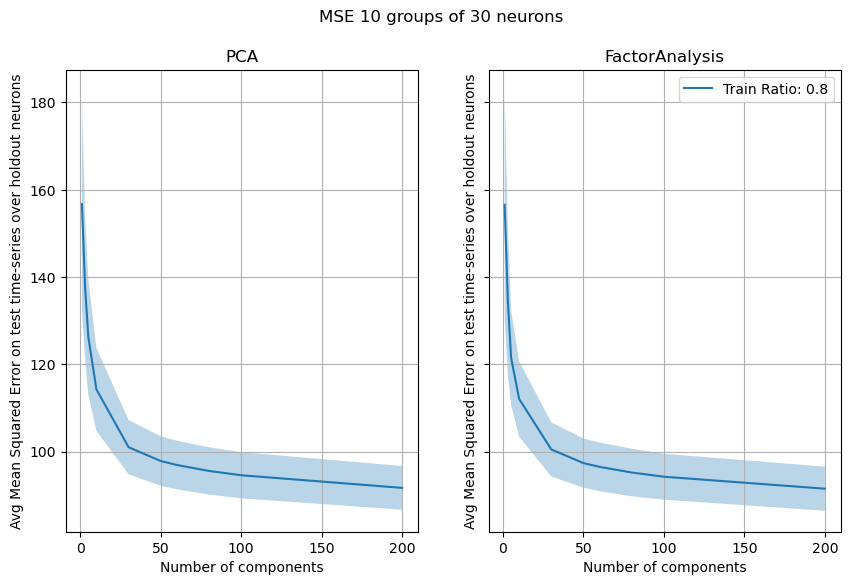

In [27]:
methods = [PCA, FactorAnalysis]
f, ax = plt.subplots(1, len(methods), figsize=(10, 6), sharey=True)
if len(methods) == 1:
  ax = [ax]
for method_i, method in enumerate(methods):
  print ("\nBeginning method: ", method.__name__, "\n", "="*70)
  full_train_errors, full_train_std_errors = test_method(method, train_times, test_n_pcs)
  ax[method_i].plot(test_n_pcs, full_train_errors, label=f'Train Ratio: 0.8')
  # 2. Define the upper and lower bounds of the error area
  lower_bound = full_train_errors - full_train_std_errors
  upper_bound = full_train_errors + full_train_std_errors
  ax[method_i].fill_between(test_n_pcs, lower_bound, upper_bound, alpha=0.3) # Use alpha for transparency
  ax[method_i].grid()
  ax[method_i].set_xlabel("Number of components")
  ax[method_i].set_ylabel("Avg Mean Squared Error on test time-series over holdout neurons")
  ax[method_i].set_title(method.__name__)
plt.legend()
plt.suptitle("MSE {} groups of {} neurons".format(n_subsets, n_neurons_per_group))
plt.savefig("results.png")
plt.show()

/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_57301/2552360946.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross = np.abs(np.cross(line_vec_norm, vecs))
/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_57301/2552360946.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross = np.abs(np.cross(line_vec_norm, vecs))


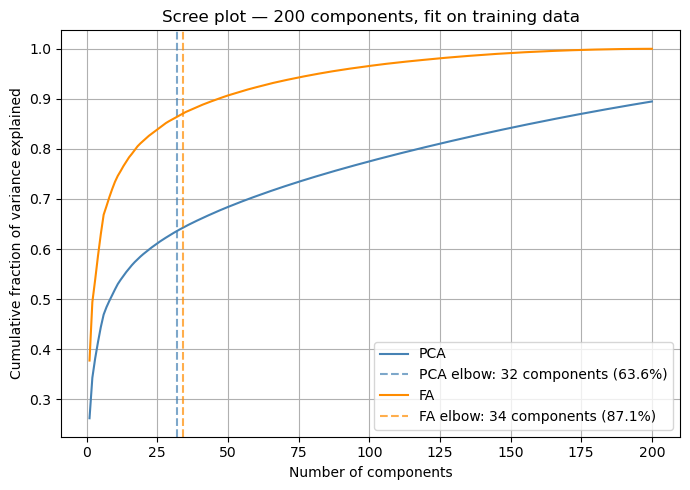

In [28]:
# Scree plots using the largest trained model (max n_components = max(test_n_pcs))
max_n_components = max(test_n_pcs)
methods = [PCA, FactorAnalysis]
colors = {'PCA': 'steelblue', 'FactorAnalysis': 'darkorange'}
labels = {'PCA': 'PCA', 'FactorAnalysis': 'FA'}

def find_elbow(values):
    """Find elbow via maximum distance from the line connecting first and last points."""
    n = len(values)
    coords = np.column_stack([np.arange(n), values])
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    vecs = coords - coords[0]
    cross = np.abs(np.cross(line_vec_norm, vecs))
    return int(np.argmax(cross))

f, ax = plt.subplots(figsize=(7, 5))
for method in methods:
    name = method.__name__
    if method == PCA:
        model = PCA(n_components=max_n_components, svd_solver='randomized')
    elif method == FactorAnalysis:
        model = FactorAnalysis(n_components=max_n_components, svd_method='randomized', max_iter=1000, tol=1e-2)

    model.fit(decomposition_train)

    if method == PCA:
        explained_var = model.explained_variance_ratio_
    elif method == FactorAnalysis:
        loadings = model.components_
        component_var = np.sum(loadings ** 2, axis=1)
        explained_var = component_var / component_var.sum()

    cumvar = np.cumsum(explained_var)
    elbow_idx = find_elbow(cumvar)
    elbow_component = elbow_idx + 1
    cumvar_at_elbow = cumvar[elbow_idx]
    color = colors[name]

    ax.plot(np.arange(1, max_n_components + 1), cumvar, color=color, label=labels[name])
    ax.axvline(x=elbow_component, color=color, linestyle='--', alpha=0.7,
               label=f'{labels[name]} elbow: {elbow_component} components ({cumvar_at_elbow:.1%})')

ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative fraction of variance explained')
ax.set_title(f'Scree plot — {max_n_components} components, fit on training data')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()


# (PREVIOUS VERSIONS BELOW)

# Using one heldout neuron
First, we tried using one holdout neuron like the paper.

In [22]:
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def test_method(method, train_time_ratio, n_components, verbose=False):
  '''
  Evaluates the performance of a dimensionality reduction method (PCA or FactorAnalysis)
  on predicting held-out neuron activity using linear regression.

  Args:
    method: The dimensionality reduction method class (PCA or FactorAnalysis).
    train_time_ratio: The ratio of the dataset to use for training (unused in the current implementation).
    n_components: The number of components to use for dimensionality reduction (unused in the current implementation).
    verbose: If True, prints progress during execution.

  Returns:
    A list of lists containing the average mean squared error for each combination
    of training time ratio and number of components.
  '''
  plot_errors = []
  full_train_errors = []
  for train_time_ratio in train_times:
    train_time = int(train_time_ratio * pca_dataset.shape[0]) # Use shape of subsampled dataset
    if verbose:
      print ("Training subset = ", train_time_ratio * 100)
    for n_components in test_n_pcs:
      if method == PCA:
          decomposition_method = method(n_components=n_components, svd_solver='randomized')
      elif method == FactorAnalysis:
          decomposition_method = method(n_components=n_components, svd_method="randomized", max_iter=200, tol=1e-3) # makes it go quicker
      else:
          raise ValueError("Unsupported method")

      line = LinearRegression()
      errors = []
      for sample_neuron in selected_neurons: # choosing sampled neurons for quicker evaluation
        # form training set of data until train_time (actually a number of frames), using all neurons except sample_neuron
        # pca_dataset should have dims (train_time,  n_neurons - 1) and transform should result in dims (train_time, n_components)
        train_transformed = decomposition_method.fit_transform(pca_dataset[:train_time, [j for j in range(neuron_range[1]) if j != sample_neuron]]) # Use the instantiated method
        # Fit a line from the n_components at each timepoint to the sample_neuron's trace at each timepoint.
        # the weight has dims (n_components, 1) which can yield a vector of (train_time, 1), i.e. sample_neuron's activity through train_time.
        line.fit(train_transformed, pca_dataset[:train_time, sample_neuron])

        # now that we have fitted parameters, test the method in the heldout data (after train_time) with the same process
        z = decomposition_method.transform(pca_dataset[train_time:, [j for j in range(neuron_range[1]) if j != sample_neuron]]) # Use the instantiated method
        prediction_ = line.predict(z)

        # this should result in a reconstruction of sample_neuron's activity after train_time. Error is then the error compared to the known trace.
        error = mean_squared_error(prediction_, pca_dataset[train_time:, sample_neuron]) # TODO: same test set; partition according to idx
        errors.append(error)
        # TODO: calculate error bars using mean error/variance error among LOOs
      print (f"Average error for {n_components} components: {np.round(np.mean(errors), 8)}")
      plot_errors.append(np.mean(errors))
    full_train_errors.append(plot_errors)
    plot_errors = []
  return full_train_errors

This should yield curves that look like this:

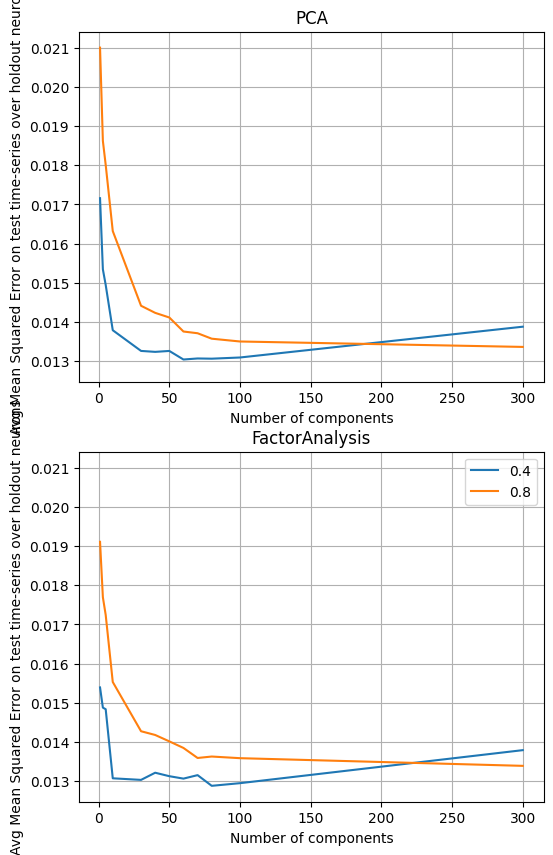

## Previous results (different cells, so not usable)

PCA over 3 splits

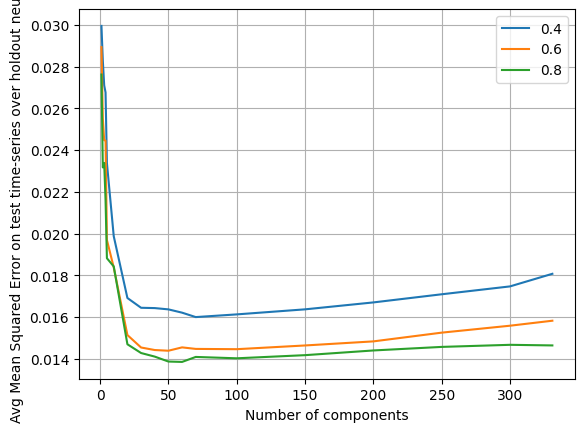

Factor Analysis over 2 splits

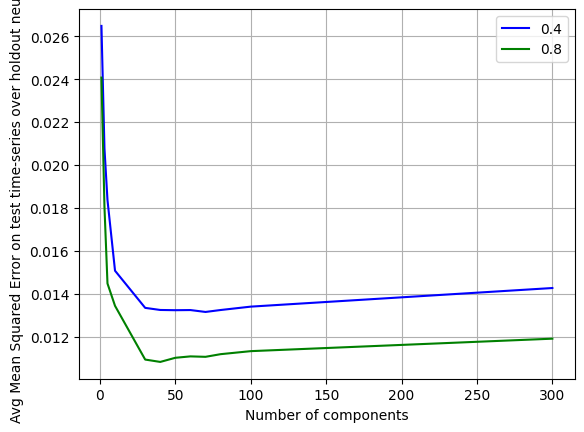

Testing PCA with train time ratio 0.4 and 1 components.
Average error for 1 components: 0.017159069189801812
Testing PCA with train time ratio 0.4 and 3 components.
Average error for 3 components: 0.015346035640686751
Testing PCA with train time ratio 0.4 and 5 components.
Average error for 5 components: 0.014947328343987465
Testing PCA with train time ratio 0.4 and 10 components.
Average error for 10 components: 0.013791709672659636
Testing PCA with train time ratio 0.4 and 30 components.
Average error for 30 components: 0.013242231542244553
Testing PCA with train time ratio 0.4 and 40 components.
Average error for 40 components: 0.01311418074183166
Testing PCA with train time ratio 0.4 and 50 components.
Average error for 50 components: 0.013236864749342204
Testing PCA with train time ratio 0.4 and 60 components.
Average error for 60 components: 0.013073312072083353
Testing PCA with train time ratio 0.4 and 70 components.
Average error for 70 components: 0.013059210497885942
Testing 

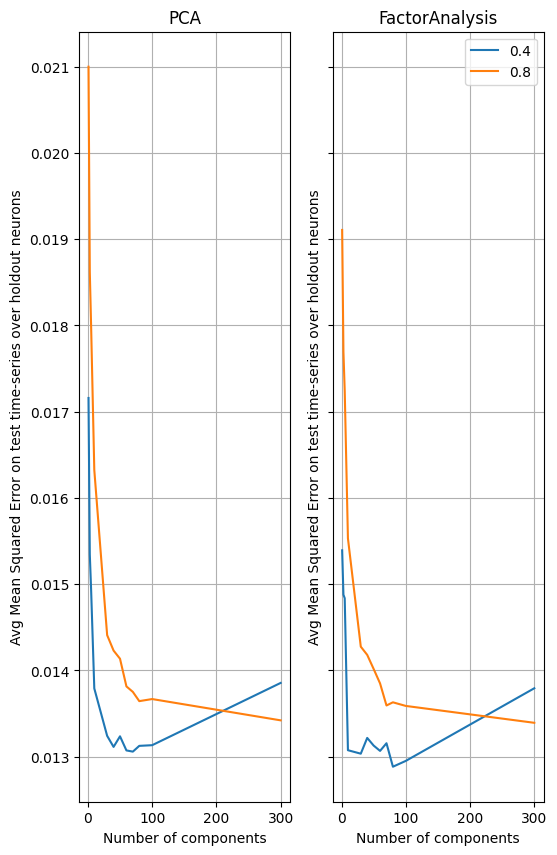

CPU times: user 21.8 s, sys: 10.4 s, total: 32.3 s
Wall time: 1h 13min 35s


In [ ]:
%%time
methods = [PCA, FactorAnalysis]
f, ax = plt.subplots(1, len(methods), figsize=(6, 10), sharey=True)
for method_i, method in enumerate(methods):
  full_train_errors = []
  for train_time_ratio in train_times:
    plot_errors = []
    for n_components in test_n_pcs:
      print(f"Testing {method.__name__} with train time ratio {train_time_ratio} and {n_components} components.")
      # Parallelize the loop over selected_neurons
      errors = Parallel(n_jobs=-1)(
          delayed(test_method)(method, train_time_ratio, n_components, sample_neuron)
          for sample_neuron in selected_neurons
      )
      avg_error = np.mean(errors)
      print (f"Average error for {n_components} components: {avg_error}")
      plot_errors.append(avg_error)
    full_train_errors.append(plot_errors)

  for train_idx, result in enumerate(full_train_errors):
    ax[method_i].plot(test_n_pcs, full_train_errors[train_idx], label=train_times[train_idx])
  ax[method_i].set_xlabel("Number of components")
  ax[method_i].set_ylabel("Avg Mean Squared Error on test time-series over holdout neurons")
  ax[method_i].set_title(method.__name__)
  ax[method_i].grid()

plt.legend()
plt.savefig("results.png")
plt.show()

In [ ]:
# Acceleration test
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# overlay with PCA n components

def test_method_vectorized(method, train_times, test_n_pcs, selected_neurons, pca_dataset, neuron_range, verbose=False):
    '''
    Vectorized evaluation of PCA or FactorAnalysis predicting held-out neurons using linear regression.
    '''
    full_train_errors = []

    for train_time_ratio in train_times:
        train_time = int(train_time_ratio * pca_dataset.shape[0])
        if verbose:
            print(f"Training subset = {train_time_ratio*100:.1f}%")

        plot_errors = []

        for n_components in test_n_pcs:
            # Initialize decomposition method
            if method == PCA:
                decomposition_method = method(n_components=n_components, svd_solver='randomized')
            elif method == FactorAnalysis:
                decomposition_method = method(n_components=n_components, svd_method='randomized')
            else:
                raise ValueError("Unsupported method")

            # Prepare training data (all neurons except selected neurons)
            all_indices = np.arange(neuron_range[1])
            other_indices = np.setdiff1d(all_indices, selected_neurons)

            # Fit decomposition on training data
            train_transformed = decomposition_method.fit_transform(pca_dataset[:train_time, other_indices])

            # Fit a linear regression to predict all selected neurons at once
            line = LinearRegression().fit(train_transformed, pca_dataset[:train_time, selected_neurons])

            # Transform test data
            test_transformed = decomposition_method.transform(pca_dataset[train_time:, other_indices])

            # Predict all selected neurons in one go
            predictions = line.predict(test_transformed)

            # Compute mean squared error per neuron
            errors = np.mean((predictions - pca_dataset[train_time:, selected_neurons])**2, axis=0)

            avg_error = np.mean(errors)
            if verbose:
                print(f"Average error for {n_components} components: {avg_error:.4f}")

            plot_errors.append(avg_error)

        full_train_errors.append(plot_errors)

    return full_train_errors
